## Sequential Workflows

## Basic Non LLM Workflow

### BMI Calculator Workflow 

State :
- Weight
- Height
- BMI

In [22]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [23]:
# Define State
class BMIState(TypedDict):
    weight_kg : float
    height_m :float
    bmi : float
    label :str
    

In [24]:
def calculate_bmi(state : BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight/ (height**2)

    state['bmi'] = round(bmi, 2)
    return state

In [25]:
def label_bmi(state :BMIState) -> BMIState:
    bmi = state['bmi']

    if bmi < 18.5:
        state['label'] = "Underweight"

    elif 18.5 <= bmi < 25 :
        state['label'] = "Fit"

    elif 25 <= bmi <30:
        state['label'] = "Overweight"
    else:
        state['label'] = "Obese"    

    return state

In [26]:
# Define you graph
graph = StateGraph(BMIState)

## Add Nodes to your graph
graph.add_node("Calculate_BMI", calculate_bmi)
graph.add_node("Category", label_bmi)

## Add edges to the graph 
graph.add_edge(START, "Calculate_BMI")
graph.add_edge("Calculate_BMI", "Category")
graph.add_edge("Category", END)

## Compile the graph
workflow = graph.compile()



In [27]:
## Execute the graph

output_state = workflow.invoke({'weight_kg': 80, 'height_m' : 1.73})

print(output_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'label': 'Overweight'}


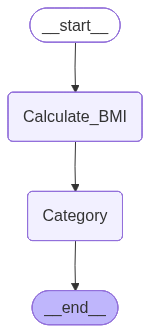

In [28]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

## LLM Workflow

In [35]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv()
import os 

In [44]:
llm = ChatOpenAI(
    model="nvidia/nemotron-3-super-120b-a12b:free",
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1",
    timeout=30,
    max_retries=2,
)

In [45]:
## create a state 

class LLMState(TypedDict):
    question :str
    answer :str
    

In [46]:
def llm_qa(state: LLMState) -> LLMState:
    # Extract the question from the state
    question = state['question']

    # form a prompt
    prompt = f"Answer the following question: {question}"

    # Ask the question from the LLM
    response = llm.invoke(prompt).content

    # Update the answer in the state
    state['answer'] = response

    return state


In [47]:
## Create the graph

graph  = StateGraph(LLMState)

## Add nodes 
graph.add_node("llm_qa", llm_qa)

graph.add_edge(START, "llm_qa")
graph.add_edge("llm_qa", END)

## Compile the graph
workflow = graph.compile()

In [48]:
initial_state = {'question' : 'How far is moon from the earth?'}

final_state = workflow.invoke(initial_state)

print(final_state)

{'question': 'How far is moon from the earth?', 'answer': 'The distance between the Earth and the Moon **is not constant** because the Moon orbits Earth in an **elliptical (oval-shaped) path**, not a perfect circle. This means the distance varies throughout the Moon\'s orbit.\n\nHere are the key figures:\n\n- **Average distance**: **384,400 kilometers** (about 238,900 miles).  \n  This is the most commonly cited value and represents the mean distance over time.\n\n- **Closest approach (perigee)**: Approximately **363,000 kilometers** (about 225,600 miles).  \n  At this point, the Moon appears slightly larger in the sky (a "supermoon" can occur near perigee).\n\n- **Farthest point (apogee)**: Approximately **405,000 kilometers** (about 251,600 miles).  \n  Here, the Moon appears slightly smaller.\n\n### Important Notes:\n- The variation is about **42,000 km** (26,000 miles) between perigee and apogee — roughly 10% of the average distance.\n- The Moon is **gradually drifting away from Ea

In [43]:
resp = llm.invoke("Say hi")
print(resp.content)

Hi!
